# Backpropagation in Multilayer Neural Networks

### Goals:
- Implementing a real gradient descent using `PyTorch` tensors

### Dataset:

- [sklearn.datasets.load_digits](http://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html#sklearn.datasets.load_digits)

In [ ]:
import torch
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

digits = load_digits()

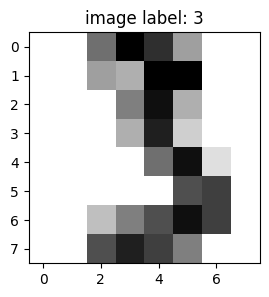

In [ ]:
sample_index = 45
plt.figure(figsize=(3, 3))
plt.imshow(digits.images[sample_index], cmap=plt.cm.gray_r,
           interpolation='nearest')
plt.title("image label: %d" % digits.target[sample_index]);
plt.show()

### Preprocessing

- Normalization
- Train / test split

In [ ]:
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

data = torch.asarray(digits.data, dtype=torch.float32)
target = torch.asarray(digits.target, dtype=torch.int32)

X_train, X_test, y_train, y_test = train_test_split(
    data, target, test_size=0.15, random_state=37)

# mean = 0 ; standard deviation = 1.0
scaler = preprocessing.StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(scaler.mean_)
print(scaler.scale_)

[0.00000000e+00 2.98624754e-01 5.19253438e+00 1.18428291e+01
 1.18565815e+01 5.81008513e+00 1.34774067e+00 1.19187950e-01
 6.54878847e-03 1.99345121e+00 1.03464309e+01 1.19305828e+01
 1.02626064e+01 8.20497708e+00 1.84348396e+00 9.88867060e-02
 3.27439424e-03 2.61624100e+00 9.83497053e+00 6.87098887e+00
 7.11263916e+00 7.83759005e+00 1.75376555e+00 4.45317616e-02
 1.30975769e-03 2.48788474e+00 9.04453176e+00 8.73280943e+00
 9.98231827e+00 7.57105435e+00 2.26850033e+00 2.61951539e-03
 0.00000000e+00 2.36149312e+00 7.68369352e+00 9.07924034e+00
 1.03713163e+01 8.79240341e+00 2.89980354e+00 0.00000000e+00
 8.51342502e-03 1.57039948e+00 6.84937787e+00 7.22855272e+00
 7.65029470e+00 8.26522593e+00 3.48592010e+00 2.61951539e-02
 8.51342502e-03 6.83693517e-01 7.49312377e+00 9.56516045e+00
 9.36869679e+00 8.77668631e+00 3.76686313e+00 2.08906352e-01
 6.54878847e-04 2.78978389e-01 5.53700065e+00 1.20595940e+01
 1.17832351e+01 6.81990832e+00 2.07465619e+00 3.42501637e-01]
[1.         0.91047427 

In [ ]:
X_train.shape

(1527, 64)

In [ ]:
X_train.dtype

dtype('float64')

In [ ]:
X_test.shape

(270, 64)

In [ ]:
y_train.shape

torch.Size([1527])

In [ ]:
y_train.dtype

torch.int32

# Torch Implementation

## a) Logistic Regression

In this section we will implement a logistic regression model trainable with SGD using PyTorch tensors. Here are the objectives:

- Implement a simple forward model with no hidden layer (equivalent to a logistic regression):
note: shape, transpose of W with regards to course
$y = softmax(\mathbf{W} \dot x + b)$

- Build a predict function which returns the most probable class given an input $x$

- Build an accuracy function for a batch of inputs $X$ and the corresponding expected outputs $y_{true}$

- Build a grad function which computes $\frac{d}{dW} -\log(softmax(W \dot x + b))$ for an $x$ and its corresponding expected output $y_{true}$ ; check that the gradients are well defined

- Build a train function which uses the grad function output to update $\mathbf{W}$ and $b$


### One-hot encoding for class label data

First let's define a helper function to compute the one hot encoding of an integer array for a fixed number of classes (similar to keras' `to_categorical`):

In [ ]:
def one_hot(n_classes, y):
    return torch.eye(n_classes)[y]

In [ ]:
one_hot(n_classes=10, y=3)

tensor([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])

In [ ]:
one_hot(n_classes=10, y=[0, 4, 9, 1])

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]])

### The softmax function

Now let's implement the softmax vector function:

$$
softmax(\mathbf{x}) = \frac{1}{\sum_{i=1}^{n}{e^{x_i}}}
\cdot
\begin{bmatrix}
  e^{x_1}\\\\
  e^{x_2}\\\\
  \vdots\\\\
  e^{x_n}
\end{bmatrix}
$$

In [ ]:
def softmax(X):
    X = torch.asarray(X)
    exp = torch.exp(X)
    return exp / torch.sum(exp, axis=-1, keepdims=True)


Make sure that this works one vector at a time (and check that the components sum to one):

> Add blockquote



In [ ]:
print(softmax([10, 2, -3]))

tensor([9.9966e-01, 3.3535e-04, 2.2596e-06])


Note that a naive implementation of softmax might not be able process a batch of activations in a single call:

In [ ]:
X = torch.asarray([[10, 2, -3],
              [-1, 5, -20]])
print(softmax(X))

tensor([[9.9966e-01, 3.3535e-04, 2.2596e-06],
        [2.4726e-03, 9.9753e-01, 1.3854e-11]])


Here is a way to implement softmax that works both for an individual vector of activations and for a batch of activation vectors at once:

In [ ]:
# def softmax(X):
#     exp = torch.exp(X)
#     return exp / torch.sum(exp, axis=-1, keepdims=True)


print("softmax of a single vector:")
print(softmax([10, 2, -3]))

softmax of a single vector:
tensor([9.9966e-01, 3.3535e-04, 2.2596e-06])


Probabilities should sum to 1:

In [ ]:
print(torch.sum(softmax([10, 2, -3])))

tensor(1.)


In [ ]:
print("softmax of 2 vectors:")
X = torch.asarray([[10, 2, -3],
              [-1, 5, -20]])
print(softmax(X))

softmax of 2 vectors:
tensor([[9.9966e-01, 3.3535e-04, 2.2596e-06],
        [2.4726e-03, 9.9753e-01, 1.3854e-11]])


The sum of probabilities for each input vector of logits should some to 1:

In [ ]:
print(torch.sum(softmax(X), axis=1))

tensor([1., 1.])


Implement a function that given the true one-hot encoded class `Y_true` and and some predicted probabilities `Y_pred` returns the negative log likelihood.

In [ ]:
def nll(Y_true, Y_pred):
    Y_true = torch.asarray(Y_true)
    Y_pred = torch.asarray(Y_pred)
    Y_pred = torch.where(Y_pred!=0, Y_pred, torch.sum(Y_pred)/1000)
    return Y_true * torch.log(Y_pred)


# Make sure that it works for a simple sample at a time
print(nll([1, 0, 0], [.99, 0.01, 0]))

tensor([-0.0101, -0.0000, -0.0000])


Check that the nll of a very confident yet bad prediction is a much higher positive number:

In [ ]:
print(nll([1, 0, 0], [0.01, 0.01, .98]))

tensor([-4.6052, -0.0000, -0.0000])


Make sure that your implementation can compute the average negative log likelihood of a group of predictions: `Y_pred` and `Y_true` can therefore be past as 2D arrays:

In [ ]:
def nll(Y_true, Y_pred, epsilon=EPSILON):
    Y_true = torch.atleast_2d(Y_true)
    Y_pred = torch.atleast_2d(Y_pred)
    # Clamp Y_pred to avoid log(0) or log of very small numbers which can lead to NaN/Inf.
    Y_pred = torch.clamp(Y_pred, epsilon, 1.0 - epsilon)
    # Negative log likelihood is -sum(Y_true * log(Y_pred)) for each sample
    return -torch.sum(Y_true * torch.log(Y_pred), dim=1)

In [ ]:
# Check that the average NLL of the following 3 almost perfect
# predictions is close to 0
Y_true = torch.asarray([[0, 1, 0],
                   [1, 0, 0],
                   [0, 0, 1]])

Y_pred = torch.asarray([[0,   1,    0],
                   [.99, 0.01, 0],
                   [0,   0,    1]])

print(nll(Y_true, Y_pred))

tensor([[    nan,  0.0000,     nan],
        [-0.0101, -0.0000,     nan],
        [    nan,     nan,  0.0000]])


Let us now study the following linear model trainable by SGD, **one sample at a time**.

In [ ]:
help(torch.outer)

Help on built-in function outer in module torch:

outer(...)
    outer(input, vec2, *, out=None) -> Tensor

    Outer product of :attr:`input` and :attr:`vec2`.
    If :attr:`input` is a vector of size :math:`n` and :attr:`vec2` is a vector of
    size :math:`m`, then :attr:`out` must be a matrix of size :math:`(n \times m)`.

    .. note:: This function does not :ref:`broadcast <broadcasting-semantics>`.

    Args:
        input (Tensor): 1-D input vector
        vec2 (Tensor): 1-D input vector

    Keyword args:
        out (Tensor, optional): optional output matrix

    Example::

        >>> v1 = torch.arange(1., 5.)
        >>> v2 = torch.arange(1., 4.)
        >>> torch.outer(v1, v2)
        tensor([[  1.,   2.,   3.],
                [  2.,   4.,   6.],
                [  3.,   6.,   9.],
                [  4.,   8.,  12.]])



tensor([[ 1,  2,  3],
        [ 2,  4,  6],
        [ 3,  6,  9],
        [ 4,  8, 12]])

In [ ]:
class LogisticRegression():

    def __init__(self, input_size, output_size):
        self.W = ((torch.rand(input_size, output_size) * 0.2) - 0.1).float()
        self.b = ((torch.rand(output_size) * 0.2) - 0.1).float()
        self.output_size = output_size

    def forward(self, X):
        Z = torch.matmul(X, self.W) + self.b
        return softmax(Z)

    def predict(self, X):
        if len(X.shape) == 1:
            return torch.argmax(self.forward(X))
        else:
            return torch.argmax(self.forward(X), axis=1)

    def grad_loss(self, x, y_true):
        y_pred = self.forward(x)
        dnll_output =  y_pred - one_hot(self.output_size, y_true)
        grad_W = torch.outer(x, dnll_output)
        grad_b = dnll_output
        grads = {"W": grad_W, "b": grad_b}
        return grads

    def train(self, x, y, learning_rate):
        # Traditional SGD update without momentum
        grads = self.grad_loss(x, y)
        self.W = self.W - learning_rate * grads["W"]
        self.b = self.b - learning_rate * grads["b"]

    def loss(self, X, y):
        return nll(one_hot(self.output_size, y), self.forward(X))

    def accuracy(self, X, y):
        y_preds = torch.argmax(self.forward(X), axis=1)
        return torch.mean((y_preds == y).float())

In [ ]:
# Convert NumPy arrays to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)


/tmp/ipython-input-1619960023.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train, dtype=torch.float32)
/tmp/ipython-input-1619960023.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test  = torch.tensor(X_test, dtype=torch.float32)
/tmp/ipython-input-1619960023.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.long)
/tmp/ipython-input-1619960023.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sou

In [ ]:
X_train.shape

torch.Size([1527, 64])

In [ ]:
# Build a model and test its forward inference
n_features = X_train.shape[1]
n_classes = len(torch.unique(y_train))
lr = LogisticRegression(n_features, n_classes)

print("Evaluation of the untrained model:")
train_loss = lr.loss(X_train, y_train)
train_acc = lr.accuracy(X_train, y_train)
test_acc = lr.accuracy(X_test, y_test)

for i in range(X_train.shape[0]):
  lr.train(X_train[i], y_train[i], 0.01)
train_loss, train_acc, test_acc

Evaluation of the untrained model:


(tensor([[-0.0000, -0.0000, -2.7867,  ..., -0.0000, -0.0000, -0.0000],
         [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -2.0672],
         [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000],
         ...,
         [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -2.0522],
         [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000],
         [-0.0000, -2.5807, -0.0000,  ..., -0.0000, -0.0000, -0.0000]]),
 tensor(0.0380),
 tensor(0.0556))

Evaluate the randomly initialized model on the first example:

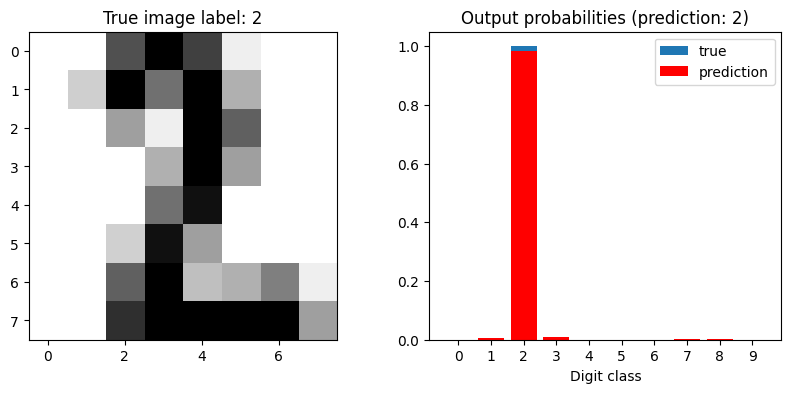

In [ ]:
def plot_prediction(model, sample_idx=0, classes=range(10)):
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

    ax0.imshow(scaler.inverse_transform(X_test[sample_idx:sample_idx+1]).reshape(8, 8),
               cmap=plt.cm.gray_r, interpolation='nearest')
    ax0.set_title("True image label: %d" % y_test[sample_idx]);


    ax1.bar(classes, one_hot(len(classes), y_test[sample_idx]), label='true')
    ax1.bar(classes, model.forward(X_test[sample_idx]), label='prediction', color="red")
    ax1.set_xticks(classes)
    prediction = model.predict(X_test[sample_idx])
    ax1.set_title('Output probabilities (prediction: %d)'
                  % prediction)
    ax1.set_xlabel('Digit class')
    ax1.legend()

plot_prediction(lr, sample_idx=0)

In [ ]:
# Training for one epoch
learning_rate = 0.01

for i, (x, y) in enumerate(zip(X_train, y_train)):
    lr.train(x, y, learning_rate)
    if i % 100 == 0:
        train_loss = lr.loss(X_train, y_train)
        train_acc = lr.accuracy(X_train, y_train)
        test_acc = lr.accuracy(X_test, y_test)
        print("Update #%d, train acc: %0.3f, test acc: %0.3f"
              % (i, train_acc, test_acc))

Update #0, train acc: 0.955, test acc: 0.952
Update #100, train acc: 0.959, test acc: 0.963
Update #200, train acc: 0.960, test acc: 0.967
Update #300, train acc: 0.960, test acc: 0.952
Update #400, train acc: 0.961, test acc: 0.956
Update #500, train acc: 0.959, test acc: 0.959
Update #600, train acc: 0.961, test acc: 0.963
Update #700, train acc: 0.963, test acc: 0.970
Update #800, train acc: 0.965, test acc: 0.974
Update #900, train acc: 0.963, test acc: 0.970
Update #1000, train acc: 0.967, test acc: 0.970
Update #1100, train acc: 0.967, test acc: 0.970
Update #1200, train acc: 0.970, test acc: 0.978
Update #1300, train acc: 0.971, test acc: 0.974
Update #1400, train acc: 0.971, test acc: 0.967
Update #1500, train acc: 0.971, test acc: 0.967


Evaluate the trained model on the first example:

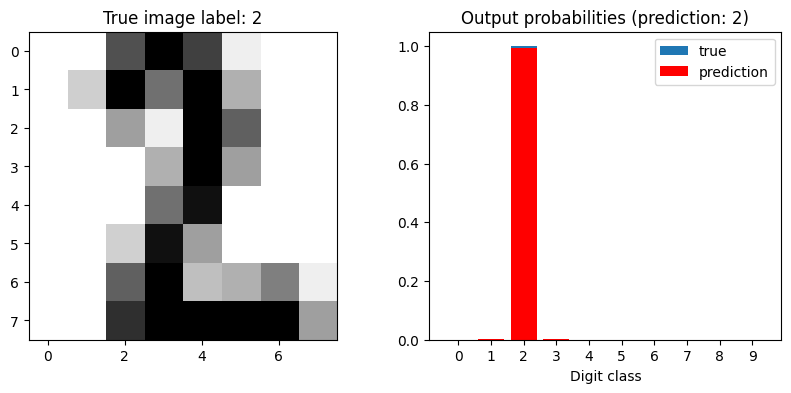

In [ ]:
plot_prediction(lr, sample_idx=0)

## b) Feedforward Multilayer

The objective of this section is to implement the backpropagation algorithm (SGD with the chain rule) on a single layer neural network using the sigmoid activation function.

- Implement the `sigmoid` and its element-wise derivative `dsigmoid` functions:

$$
sigmoid(x) = \frac{1}{1 + e^{-x}}
$$

$$
dsigmoid(x) = sigmoid(x) \cdot (1 - sigmoid(x))
$$

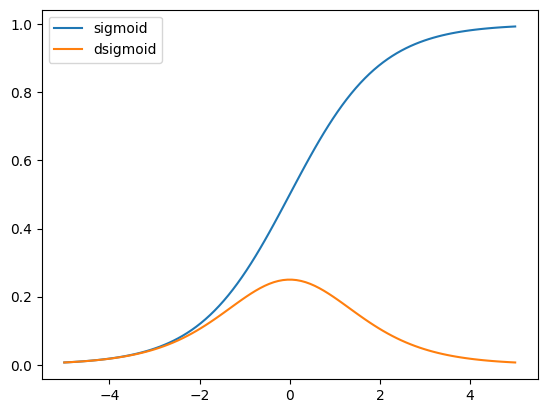

In [ ]:
def sigmoid(X):
    return torch.sigmoid(X)


def dsigmoid(X):
    return sigmoid(X) * (1 - sigmoid(X))


x = torch.linspace(-5, 5, 100)
plt.plot(x, sigmoid(x), label='sigmoid')
plt.plot(x, dsigmoid(x), label='dsigmoid')
plt.legend(loc='best');

- Implement `forward` and `forward_keep_all` functions for a model with a hidden layer with a sigmoid activation function:
  - $\mathbf{h} = sigmoid(\mathbf{W}^h \mathbf{x} + \mathbf{b^h})$
  - $\mathbf{y} = softmax(\mathbf{W}^o \mathbf{h} + \mathbf{b^o})$

- Notes:
  - try to keep the code as similar as possible as the previous one;
  - `forward` now has a keep activations parameter to also return hidden activations and pre activations;

- Update the grad function to compute all gradients; check that the gradients are well defined;

- Implement the `train` and `loss` functions.

**Bonus**: reimplementing all from scratch only using the lecture slides but without looking at the solution of the `LogisticRegression` is an excellent exercise.

In [ ]:
EPSILON = 1e-8


class NeuralNet():
    """MLP with 1 hidden layer with a sigmoid activation"""

    def __init__(self, input_size, hidden_size, output_size):

        self.W_h = (torch.rand(input_size, hidden_size) * 0.2) - 0.1
        self.b_h = (torch.rand(hidden_size) * 0.2) - 0.1
        self.W_o = (torch.rand(hidden_size, output_size) * 0.2) - 0.1
        self.b_o = (torch.rand(output_size) * 0.2) - 0.1
        self.output_size = output_size

    def forward_keep_activations(self, X):

        X=torch.as_tensor(X, dtype=torch.float32)
        z_h = torch.matmul(X, self.W_h) + self.b_h
        h = sigmoid(z_h)
        z_o= torch.matmul(h, self.W_o) + self.b_o
        y = softmax(z_o)
        return y, h, z_h

    def forward(self, X):
        y, _, _ = self.forward_keep_activations(X)
        return y


    def loss(self, X, y):
        y_pred = self.forward(X)
        y_true_oh = one_hot(self.output_size, y)
        return -torch.mean(torch.sum(
            y_true_oh * torch.log(y_pred + EPSILON), dim=1
        ))


    def grad_loss(self, x, y_true):

        if x.ndim == 1:
            x_in = x.unsqueeze(0)
        else:
            x_in = x

        y_pred, h, z_h = self.forward_keep_activations(x_in)
        y_true_oh = one_hot(self.output_size, y_true)

        error_output = (y_pred - y_true_oh).squeeze()
        h_vec = h.squeeze()

        grad_W_o = torch.outer(h_vec, error_output)
        grad_b_o = error_output

        error_hidden = torch.matmul(error_output, self.W_o.T) * dsigmoid(z_h.squeeze())

        grad_W_h = torch.outer(x.squeeze(), error_hidden)
        grad_b_h = error_hidden

        return {"W_h": grad_W_h, "b_h": grad_b_h, "W_o": grad_W_o, "b_o": grad_b_o}

    def train(self, x, y, learning_rate):
        grads = self.grad_loss(x, y)
        self.W_h = self.W_h - learning_rate * grads["W_h"]
        self.b_h = self.b_h - learning_rate * grads["b_h"]
        self.W_o = self.W_o - learning_rate* grads["W_o"]
        self.b_o = self.b_o - learning_rate* grads["b_o"]


    def predict(self, X):
        if len(X.shape) == 1:
            return torch.argmax(self.forward(X))
        else:
            return torch.argmax(self.forward(X), axis=1)

    def accuracy(self, X, y):
        y_preds = torch.argmax(self.forward(X), axis=1)
        return torch.mean((y_preds == y).float())

In [ ]:
n_hidden = 10
model = NeuralNet(n_features, n_hidden, n_classes)

In [ ]:
model.loss(X_train, y_train)

tensor(2.3113)

In [ ]:
model.accuracy(X_train, y_train)

tensor(0.0982)

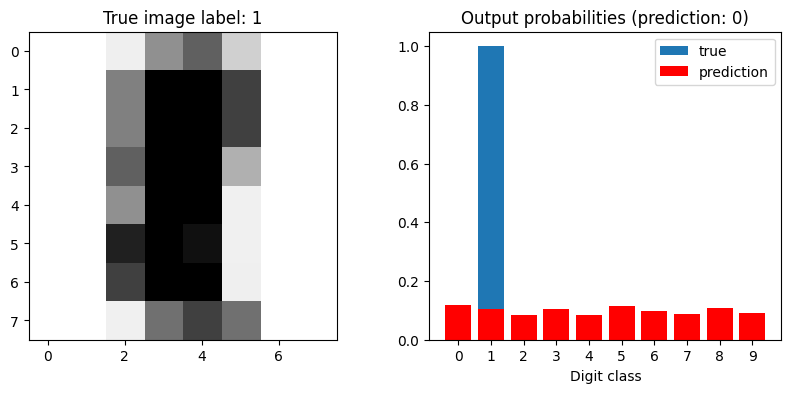

In [ ]:
plot_prediction(model, sample_idx=5)

In [ ]:
losses, accuracies, accuracies_test = [], [], []
losses.append(model.loss(X_train, y_train).sum())
accuracies.append(model.accuracy(X_train, y_train))
accuracies_test.append(model.accuracy(X_test, y_test))

print("Random init: train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
      % (losses[-1], accuracies[-1], accuracies_test[-1]))

for epoch in range(15):
    for i, (x, y) in enumerate(zip(X_train, y_train)):
        model.train(x, y, 0.1)

    losses.append(model.loss(X_train, y_train).sum())
    accuracies.append(model.accuracy(X_train, y_train))
    accuracies_test.append(model.accuracy(X_test, y_test))
    print("Epoch #%d, train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
          % (epoch + 1, losses[-1], accuracies[-1], accuracies_test[-1]))

Random init: train loss: 2.31132, train acc: 0.098, test acc: 0.115
Epoch #1, train loss: 0.28043, train acc: 0.931, test acc: 0.911
Epoch #2, train loss: 0.15969, train acc: 0.962, test acc: 0.919
Epoch #3, train loss: 0.10489, train acc: 0.976, test acc: 0.944
Epoch #4, train loss: 0.08046, train acc: 0.986, test acc: 0.956
Epoch #5, train loss: 0.06509, train acc: 0.990, test acc: 0.959
Epoch #6, train loss: 0.05289, train acc: 0.993, test acc: 0.967
Epoch #7, train loss: 0.04342, train acc: 0.995, test acc: 0.974
Epoch #8, train loss: 0.03772, train acc: 0.996, test acc: 0.974
Epoch #9, train loss: 0.03286, train acc: 0.996, test acc: 0.974
Epoch #10, train loss: 0.02929, train acc: 0.997, test acc: 0.974
Epoch #11, train loss: 0.02646, train acc: 0.997, test acc: 0.974
Epoch #12, train loss: 0.02415, train acc: 0.997, test acc: 0.974
Epoch #13, train loss: 0.02208, train acc: 0.997, test acc: 0.974
Epoch #14, train loss: 0.02041, train acc: 0.997, test acc: 0.974
Epoch #15, train 

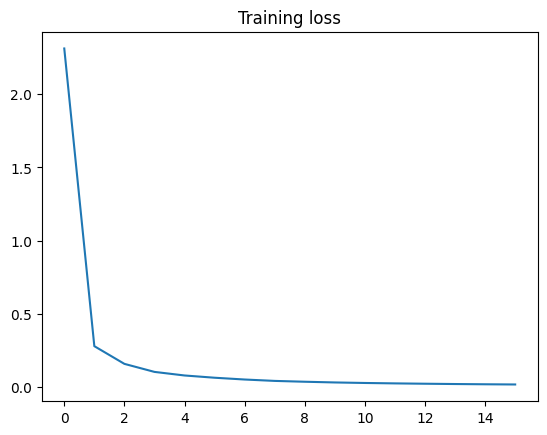

In [ ]:
plt.plot(losses)
plt.title("Training loss");

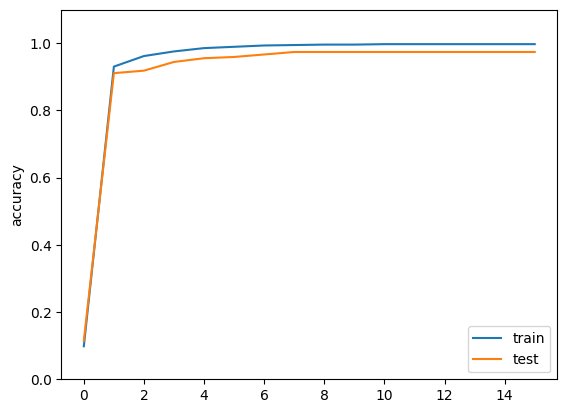

In [ ]:
plt.plot(accuracies, label='train')
plt.plot(accuracies_test, label='test')
plt.ylim(0, 1.1)
plt.ylabel("Accuracy -")
plt.legend(loc='best');

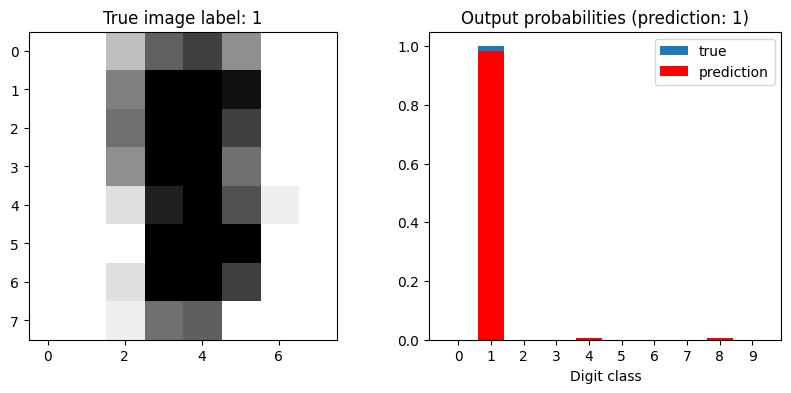

In [ ]:
plot_prediction(model, sample_idx=4)

## c) Exercises

### Look at worst prediction errors

- Use torch to find test samples for which the model made the worst predictions,
- Use the `plot_prediction` to look at the model predictions on those,
- Would you have done any better?

In [ ]:
y_pred_test = model.forward(X_test)
y_test_oh = one_hot(model.output_size, y_test)

eps = 1e-10
test_losses = -torch.sum(y_test_oh * torch.log(torch.clamp(y_pred_test, min=eps)), dim=1)

worst_indices = torch.argsort(test_losses, descending=True)[:3]

for idx in worst_indices:
    print(f"Index: {idx}, Loss: {test_losses[idx]:.4f}, Correct Label: {y_test[idx]}")

Index: 107, Loss: 7.1844, Correct Label: 5
Index: 207, Loss: 2.4571, Correct Label: 5
Index: 170, Loss: 2.1943, Correct Label: 5


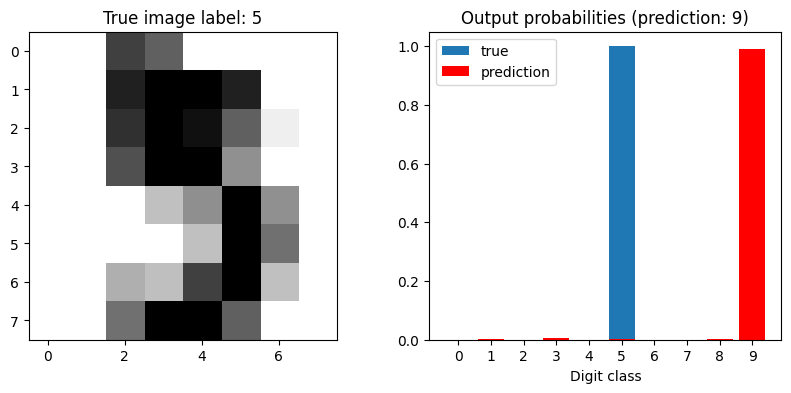

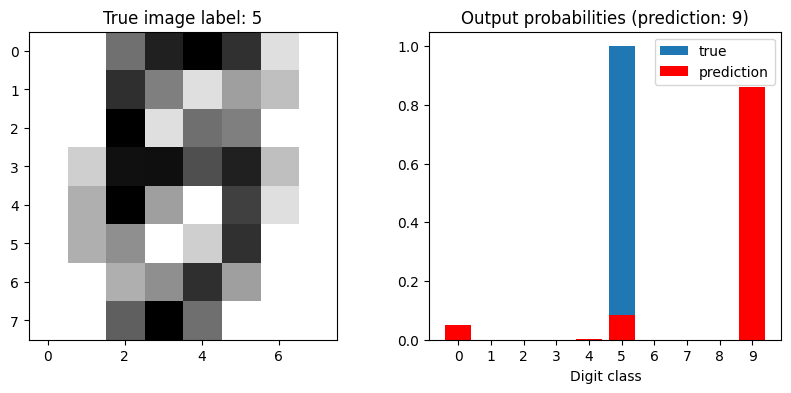

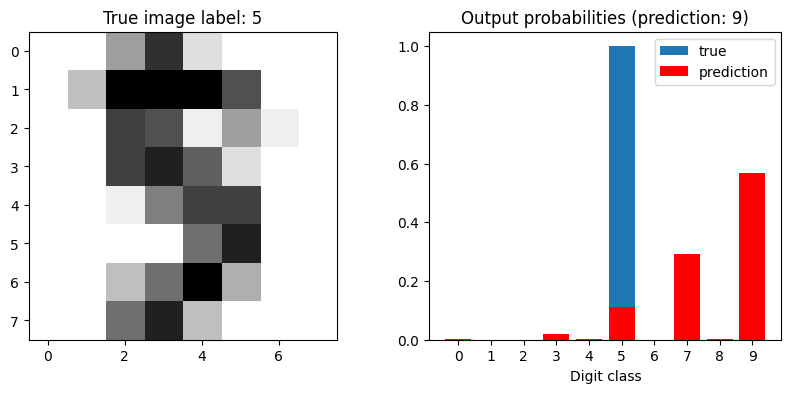

In [ ]:
for idx in worst_indices:
    idx_int = idx.item()
    plot_prediction(model, sample_idx=idx_int)
    plt.show()

### Hyper parameters settings

- Experiment with different hyper parameters:
  - learning rate,
  - size of hidden layer,
  - initialization scheme: test with 0 initialization vs uniform,
  - implement other activation functions,
  - implement the support for a second hidden layer.


### Mini-batches

- The current implementations of `train` and `grad_loss` function currently only accept a single sample at a time:
    - implement the support for training with a mini-batch of 32 samples at a time instead of one,
    - experiment with different sizes of batches,
    - monitor the norm of the average gradients on the full training set at the end of each epoch.

with momentum

In [ ]:
def relu(X):
    return torch.maximum(torch.zeros_like(X), X)

def drelu(X):
    return (X > 0).float()

def tanh(X):
    return torch.tanh(X)

def dtanh(X):
    return 1 - torch.tanh(X)**2

In [ ]:
class DeepNeuralNet():

    def __init__(self, input_size, h1_size, h2_size, output_size, init_type='uniform'):
        self.output_size = output_size

        if init_type == 'zeros':
            self.W1 = torch.zeros(input_size, h1_size)
            self.W2 = torch.zeros(h1_size, h2_size)
            self.Wo = torch.zeros(h2_size, output_size)
        else:
            self.W1 = (torch.rand(input_size, h1_size) * 0.2) - 0.1
            self.W2 = (torch.rand(h1_size, h2_size) * 0.2) - 0.1
            self.Wo = (torch.rand(h2_size, output_size) * 0.2) - 0.1

        self.b1 = torch.zeros(h1_size)
        self.b2 = torch.zeros(h2_size)
        self.bo = torch.zeros(output_size)

        self.vW1, self.vb1 = torch.zeros_like(self.W1), torch.zeros_like(self.b1)
        self.vW2, self.vb2 = torch.zeros_like(self.W2), torch.zeros_like(self.b2)
        self.vWo, self.vbo = torch.zeros_like(self.Wo), torch.zeros_like(self.bo)

    def forward_keep_activations(self, X):
        X = torch.as_tensor(X, dtype=torch.float32)

        z1 = torch.matmul(X, self.W1) + self.b1
        h1 = sigmoid(z1)   #change here the diffrent activation as implemented above

        z2 = torch.matmul(h1, self.W2) + self.b2
        h2 = sigmoid(z2)

        zo = torch.matmul(h2, self.Wo) + self.bo
        y = softmax(zo)

        return y, h2, z2, h1, z1

    def forward(self, X):
        y, _, _, _, _ = self.forward_keep_activations(X)
        return y

    def grad_loss(self, x, y_true):
        if x.ndim == 1: x = x.unsqueeze(0)

        y_pred, h2, z2, h1, z1 = self.forward_keep_activations(x)
        y_true_oh = one_hot(self.output_size, y_true)

        error_o = y_pred - y_true_oh
        grad_Wo = torch.matmul(h2.t(), error_o)
        grad_bo = torch.sum(error_o, dim=0)

        error_h2 = torch.matmul(error_o, self.Wo.t()) * dsigmoid(z2)
        grad_W2 = torch.matmul(h1.t(), error_h2)
        grad_b2 = torch.sum(error_h2, dim=0)

        error_h1 = torch.matmul(error_h2, self.W2.t()) * dsigmoid(z1)
        grad_W1 = torch.matmul(x.t(), error_h1)
        grad_b1 = torch.sum(error_h1, dim=0)

        return {"W1": grad_W1, "b1": grad_b1, "W2": grad_W2, "b2": grad_b2, "Wo": grad_Wo, "bo": grad_bo}

    def train(self, x, y, lr, mu=0.9):
        batch_size = x.shape[0]
        grads = self.grad_loss(x, y)

        self.vW1 = mu * self.vW1 - (lr / batch_size) * grads["W1"]
        self.W1 += self.vW1
        self.vb1 = mu * self.vb1 - (lr / batch_size) * grads["b1"]
        self.b1 += self.vb1

        self.vW2 = mu * self.vW2 - (lr / batch_size) * grads["W2"]
        self.W2 += self.vW2
        self.vb2 = mu * self.vb2 - (lr / batch_size) * grads["b2"]
        self.b2 += self.vb2

        self.vWo = mu * self.vWo - (lr / batch_size) * grads["Wo"]
        self.Wo += self.vWo
        self.vbo = mu * self.vbo - (lr / batch_size) * grads["bo"]
        self.bo += self.vbo

    def loss(self, X, y):
        return nll(one_hot(self.output_size, y), self.forward(X))

    def accuracy(self, X, y):
        y_preds = torch.argmax(self.forward(X), axis=1)
        return torch.mean((y_preds == y).float())

In [ ]:
momentum = 0.9
batch_size = 32
learning_rate = 0.1
h1_size = 64
h2_size = 32

In [ ]:
model = DeepNeuralNet(n_features, h1_size, h2_size, n_classes)

In [ ]:
for epoch in range(20):
    indices = torch.randperm(X_train.shape[0])

    for i in range(0, X_train.shape[0], batch_size):
        batch_idx = indices[i : i + batch_size]
        x_batch = X_train[batch_idx]
        y_batch = y_train[batch_idx]

        model.train(x_batch, y_batch, lr=learning_rate, mu=momentum)

    current_acc = model.accuracy(X_test, y_test)
    print(f"Epoch {epoch+1}, Test Accuracy: {current_acc:.4f}")

Epoch 1, Test Accuracy: 0.0963
Epoch 2, Test Accuracy: 0.2148
Epoch 3, Test Accuracy: 0.6926
Epoch 4, Test Accuracy: 0.7852
Epoch 5, Test Accuracy: 0.8519
Epoch 6, Test Accuracy: 0.9074
Epoch 7, Test Accuracy: 0.9333
Epoch 8, Test Accuracy: 0.9370
Epoch 9, Test Accuracy: 0.9296
Epoch 10, Test Accuracy: 0.9444
Epoch 11, Test Accuracy: 0.9407
Epoch 12, Test Accuracy: 0.9407
Epoch 13, Test Accuracy: 0.9407
Epoch 14, Test Accuracy: 0.9444
Epoch 15, Test Accuracy: 0.9481
Epoch 16, Test Accuracy: 0.9481
Epoch 17, Test Accuracy: 0.9556
Epoch 18, Test Accuracy: 0.9481
Epoch 19, Test Accuracy: 0.9519
Epoch 20, Test Accuracy: 0.9556


In [ ]:
y_pred_test = model.forward(X_test)
y_test_oh = one_hot(model.output_size, y_test)

eps = 1e-10
test_losses = -torch.sum(y_test_oh * torch.log(torch.clamp(y_pred_test, min=eps)), dim=1)

worst_indices = torch.argsort(test_losses, descending=True)[:3]

for idx in worst_indices:
    print(f"Index: {idx}, Loss: {test_losses[idx]:.4f}, Correct Label: {y_test[idx]}")

Index: 107, Loss: 5.8808, Correct Label: 5
Index: 11, Loss: 2.8710, Correct Label: 2
Index: 170, Loss: 2.6893, Correct Label: 5
